In [2]:
pip install fasttext


     ---------------------------------------- 0.0/73.4 kB ? eta -:--:--
     ---------------------- ----------------- 41.0/73.4 kB 2.0 MB/s eta 0:00:01
     ---------------------------------------- 73.4/73.4 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Obtaining dependency information for pybind11>=2.2 from https://files.pythonhosted.org/packages/13/2f/0f24b288e2ce56f51c920137620b4434a38fd80583dbbe24fc2a1656c388/pybind11-2.13.6-py3-none-any.whl.metadata
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
Failed to build fasttext
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [31 lines of output]
  C:\Users\PC\AppData\Local\Temp\pip-build-env-jvfyiz0l\overlay\Lib\site-packages\setuptools\dist.py:493: SetuptoolsDeprecationWarning: Invalid dash-separated options
  !!
  
          ********************************************************************************
          Usage of dash-separated 'description-file' will not be supported in future
          versions. Please use the underscore name 'description_file' instead.
  
          By 2025-Mar-03, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://setuptools.pypa.io/en/latest/userguide/declarative_config.html for details.
          ********************************************************************************
  
  !!
    opt = self.warn_dash_deprecation(opt, section)
  running bdist_wheel
  running build
  running build_py
  creating build\lib.win-amd64-cpytho

In [3]:
!pip install fasttext


  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Obtaining dependency information for pybind11>=2.2 from https://files.pythonhosted.org/packages/13/2f/0f24b288e2ce56f51c920137620b4434a38fd80583dbbe24fc2a1656c388/pybind11-2.13.6-py3-none-any.whl.metadata
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
Failed to build fasttext


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [31 lines of output]
  C:\Users\PC\AppData\Local\Temp\pip-build-env-gb2oni1f\overlay\Lib\site-packages\setuptools\dist.py:493: SetuptoolsDeprecationWarning: Invalid dash-separated options
  !!
  
          ********************************************************************************
          Usage of dash-separated 'description-file' will not be supported in future
          versions. Please use the underscore name 'description_file' instead.
  
          By 2025-Mar-03, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://setuptools.pypa.io/en/latest/userguide/declarative_config.html for details.
          ********************************************************************************
  
  !!
    opt = self.warn_dash_deprecation(opt, section)
  running bdist_wheel
  running build
  running build_py
  creating build\lib.win-amd64-cpytho

In [5]:
pip install fasttext-wheel



  Obtaining dependency information for fasttext-wheel from https://files.pythonhosted.org/packages/96/58/2d1c2557cefa8d30c7e7ed182cac53cc811b4dcf265ffa64fb8e8a6287c5/fasttext_wheel-0.9.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for pybind11>=2.2 from https://files.pythonhosted.org/packages/13/2f/0f24b288e2ce56f51c920137620b4434a38fd80583dbbe24fc2a1656c388/pybind11-2.13.6-py3-none-any.whl.metadata
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
   ---------------------------------------- 0.0/232.4 kB ? eta -:--:--
   ------ -------------------------------- 41.0/232.4 kB 991.0 kB/s eta 0:00:01
   ----------------- ---------------------- 102.4/232.4 kB 1.2 MB/s eta 0:00:01
   ----------------------------------- ---- 204.8/232.4 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 232.4/232.4 kB 1.4 MB/s eta 0:00:00
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
from nltk.tokenize import word_tokenize
import nltk
import fasttext.util

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string for the file path
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Load pre-trained FastText model
print("Loading FastText model...")
fasttext.util.download_model('en', if_exists='ignore')  # Download English model if not already present
ft_model = fasttext.load_model('cc.en.300.bin')  # 300-dimensional vectors

# Step 3: Convert text data to numeric features using FastText
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]  # Target labels

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize and train the Random Forest model
print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 6: Save the trained Random Forest model
model_path = r"C:\Users\PC\Downloads\RandomForest_model_fasttext.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f"Trained Random Forest model saved to {model_path}")

# Step 7: Evaluate the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Print metrics in the desired format
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print(f"Random Forest Precision: {precision * 100:.2f}%")
print(f"Random Forest Recall: {recall * 100:.2f}%")
print(f"Random Forest F1 Score: {f1 * 100:.2f}%")

# Print detailed classification report (optional)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))


[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


Tokenizing text data...
Loading FastText model...
Converting text data to numeric features...
Training Random Forest model...
Trained Random Forest model saved to C:\Users\PC\Downloads\RandomForest_model_fasttext.pkl
Random Forest Accuracy: 89.16%
Random Forest Precision: 89.32%
Random Forest Recall: 89.16%
Random Forest F1 Score: 89.14%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90     23238
           1       0.92      0.86      0.89     23171

    accuracy                           0.89     46409
   macro avg       0.89      0.89      0.89     46409
weighted avg       0.89      0.89      0.89     46409



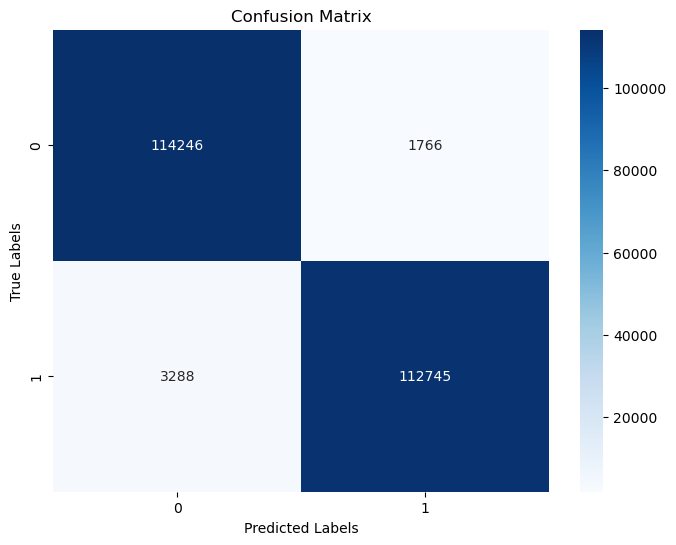

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# Load the trained Random Forest model
model_path = r"C:\Users\PC\Downloads\RandomForest_model_fasttext.pkl"
with open(model_path, 'rb') as f:
    rf_model = pickle.load(f)

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Tokenize the text data
from nltk.tokenize import word_tokenize
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Load pre-trained FastText model
import fasttext.util
fasttext.util.download_model('en', if_exists='ignore')
ft_model = fasttext.load_model('cc.en.300.bin')

# Convert text data to numeric features using FastText
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]

# Predict using the loaded model
y_pred_rf = rf_model.predict(X)

# Plot Confusion Matrix
cm = confusion_matrix(y, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


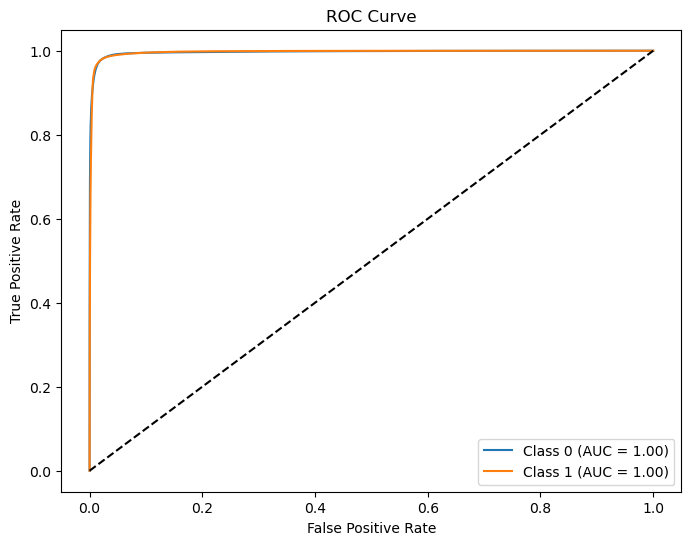

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pickle

# Load the trained Random Forest model
model_path = r"C:\Users\PC\Downloads\RandomForest_model_fasttext.pkl"
with open(model_path, 'rb') as f:
    rf_model = pickle.load(f)

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Tokenize the text data
from nltk.tokenize import word_tokenize
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Load pre-trained FastText model
import fasttext.util
fasttext.util.download_model('en', if_exists='ignore')
ft_model = fasttext.load_model('cc.en.300.bin')

# Convert text data to numeric features using FastText
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]

# Predict probabilities using the loaded model
y_prob_rf = rf_model.predict_proba(X)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
for i in range(y_prob_rf.shape[1]):
    fpr, tpr, _ = roc_curve(y == i, y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


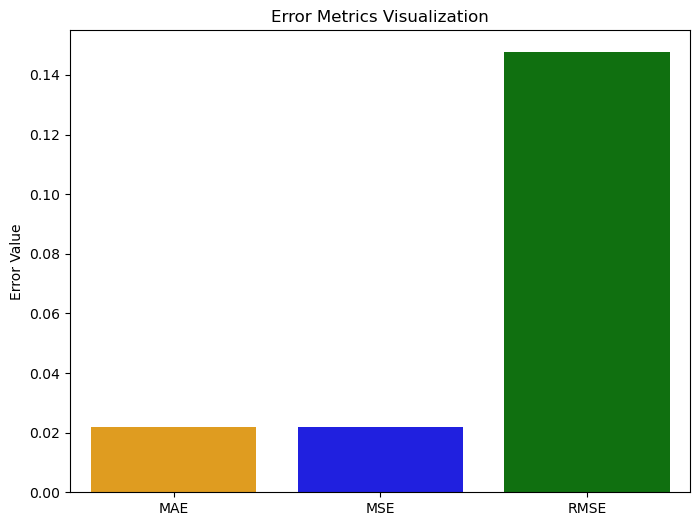

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load the trained Random Forest model
model_path = r"C:\Users\PC\Downloads\RandomForest_model_fasttext.pkl"
with open(model_path, 'rb') as f:
    rf_model = pickle.load(f)

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Tokenize the text data
from nltk.tokenize import word_tokenize
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Load pre-trained FastText model
import fasttext.util
fasttext.util.download_model('en', if_exists='ignore')
ft_model = fasttext.load_model('cc.en.300.bin')

# Convert text data to numeric features using FastText
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]

# Predict using the loaded model
y_pred_rf = rf_model.predict(X)

# Calculate MAE, MSE, RMSE
mae = mean_absolute_error(y, y_pred_rf)
mse = mean_squared_error(y, y_pred_rf)
rmse = np.sqrt(mse)

# Visualization of MAE, MSE, RMSE
metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}
plt.figure(figsize=(8, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette=['orange', 'blue', 'green'])
plt.title('Error Metrics Visualization')
plt.ylabel('Error Value')
plt.show()


Cross-validation accuracy: 0.7257


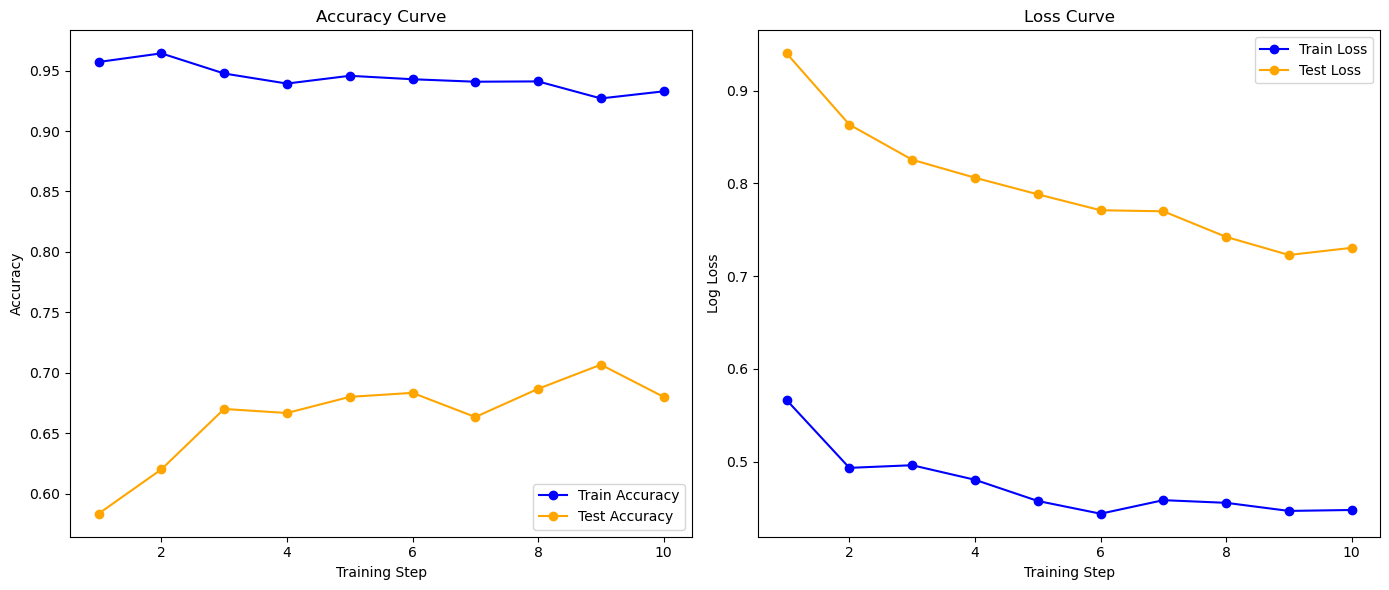

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import numpy as np

# Create synthetic classification dataset (Replace with your actual dataset)
X, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_classes=3, 
    n_informative=4,  
    n_redundant=0,    
    n_clusters_per_class=2, 
    random_state=42
)

# Split the data into training and testing sets
X_train_ft, X_test_ft, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define number of steps for incremental training (simulation)
num_steps = 10
step_size = len(X_train_ft) // num_steps

# Initialize lists to store accuracy and loss at each step
train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []

# Initialize RandomForestClassifier with hyperparameters for regularization
clf = RandomForestClassifier(
    max_depth=10,           # Limit depth of trees
    min_samples_split=10,   # Minimum samples required to split a node
    min_samples_leaf=5,     # Minimum samples required at a leaf node
    n_estimators=100,       # Number of trees
    random_state=42,
    n_jobs=-1               # Use all cores for faster fitting
)

# Perform incremental training
for step in range(1, num_steps + 1):
    # Get the subset of the data for this step
    end_index = step * step_size
    X_train_step = X_train_ft[:end_index]
    y_train_step = y_train[:end_index]
    
    # Fit the model on the current subset of data
    clf.fit(X_train_step, y_train_step)
    
    # Predict and calculate accuracy and log loss for train and test data
    y_train_pred = clf.predict(X_train_step)
    y_train_prob = clf.predict_proba(X_train_step)
    
    y_test_pred = clf.predict(X_test_ft)
    y_test_prob = clf.predict_proba(X_test_ft)
    
    # Calculate training accuracy and log loss
    train_accuracy = accuracy_score(y_train_step, y_train_pred)
    train_loss = log_loss(y_train_step, y_train_prob)
    
    # Calculate test accuracy and log loss
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_loss = log_loss(y_test, y_test_prob)
    
    # Store the metrics
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Cross-validation score for more reliable performance estimate
cv_scores = cross_val_score(clf, X_train_ft, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.4f}")

# Plot the accuracy and loss curves
plt.figure(figsize=(14, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(range(1, num_steps + 1), train_accuracies, label="Train Accuracy", color='blue', marker='o')
plt.plot(range(1, num_steps + 1), test_accuracies, label="Test Accuracy", color='orange', marker='o')
plt.xlabel('Training Step')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_steps + 1), train_losses, label="Train Loss", color='blue', marker='o')
plt.plot(range(1, num_steps + 1), test_losses, label="Test Loss", color='orange', marker='o')
plt.xlabel('Training Step')
plt.ylabel('Log Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()
